# 05 - Evaluation & Visualization

Final results loaded from `results/metrics.json` (produced by `run_pipeline.py`, which trains all six models including the LSTM).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
from IPython.display import Image, display
import json
m = json.load(open('../results/metrics.json'))
df = pd.DataFrame(m['results']).T
df = df[['RMSE','MAE','R2','skill_vs_persistence_%']].sort_values('RMSE')
print('best model:', m['best_model'])
df.round(3)

best model: XGBoost


,RMSE,MAE,R2,skill_vs_persistence_%
XGBoost,2.235,1.577,0.807,19.87
LightGBM,2.282,1.646,0.799,18.21
Ridge,2.723,2.079,0.714,2.37
Persistence,2.790,1.769,0.700,0.00
LSTM,3.425,2.376,0.551,-22.78
SeasonalNaive,4.839,3.357,0.098,-73.46


### Predicted vs ground truth, residuals, comparison, importance

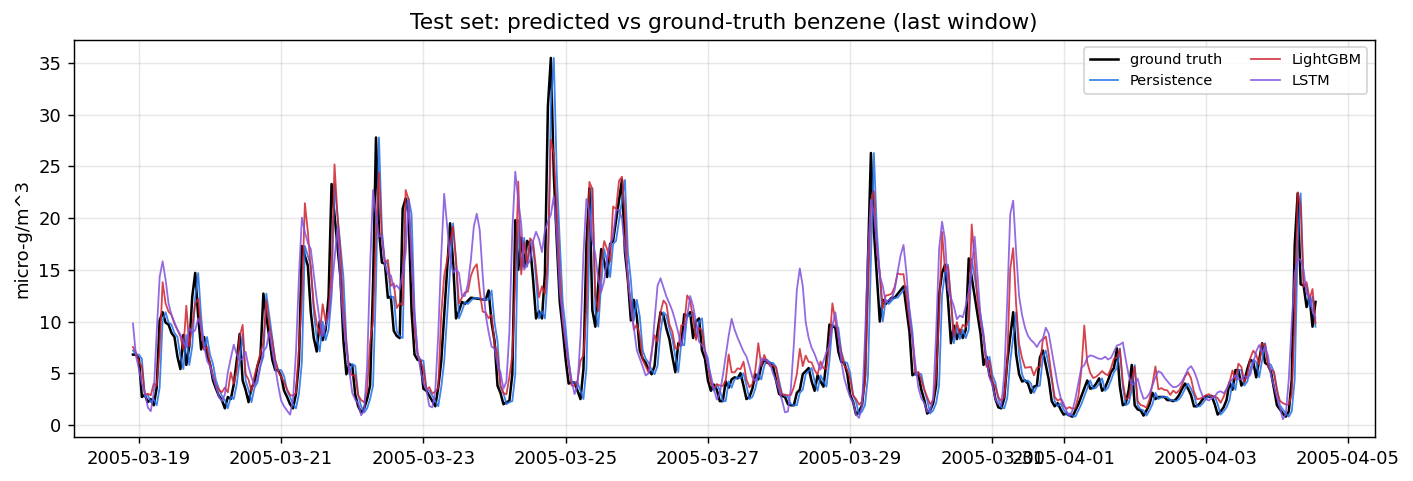

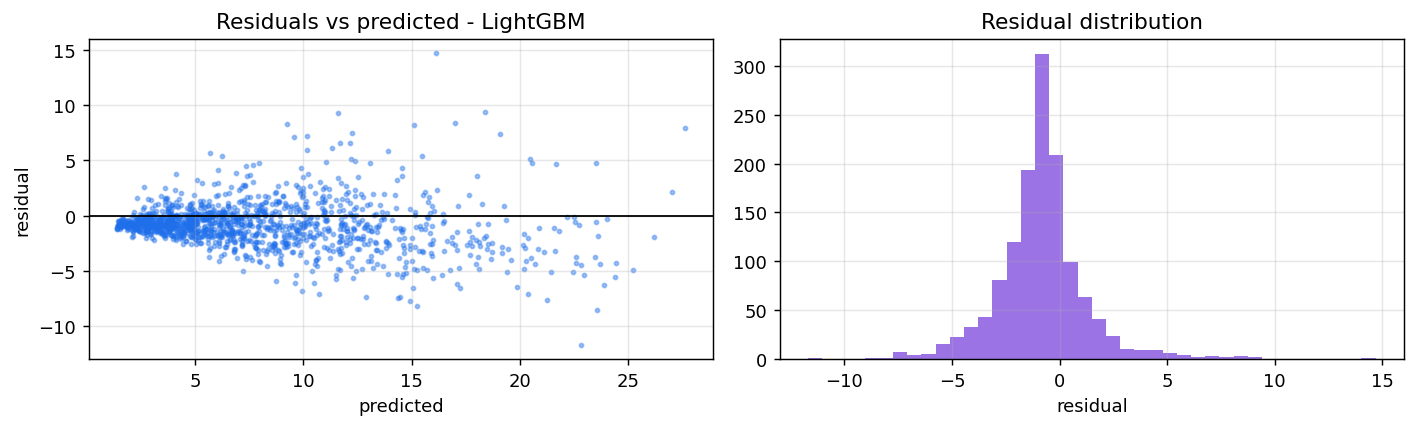

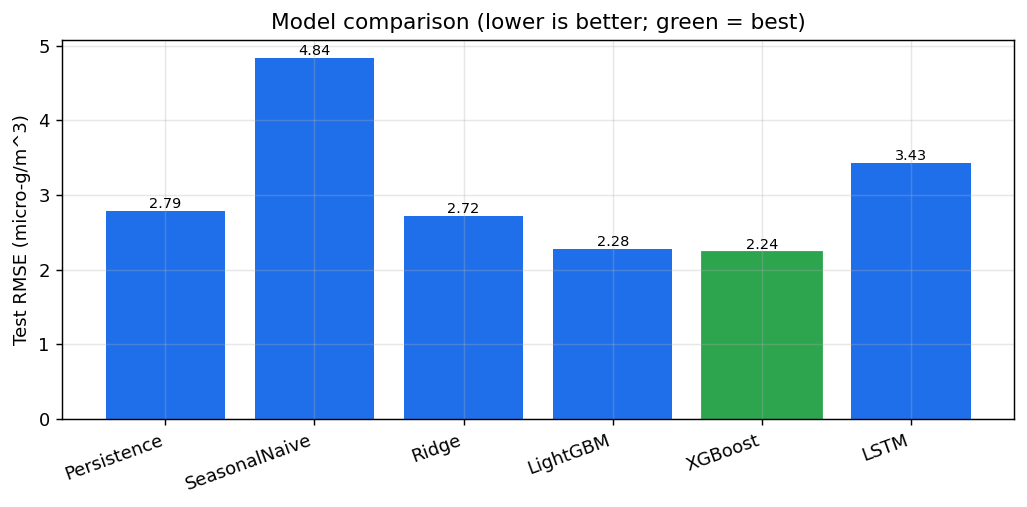

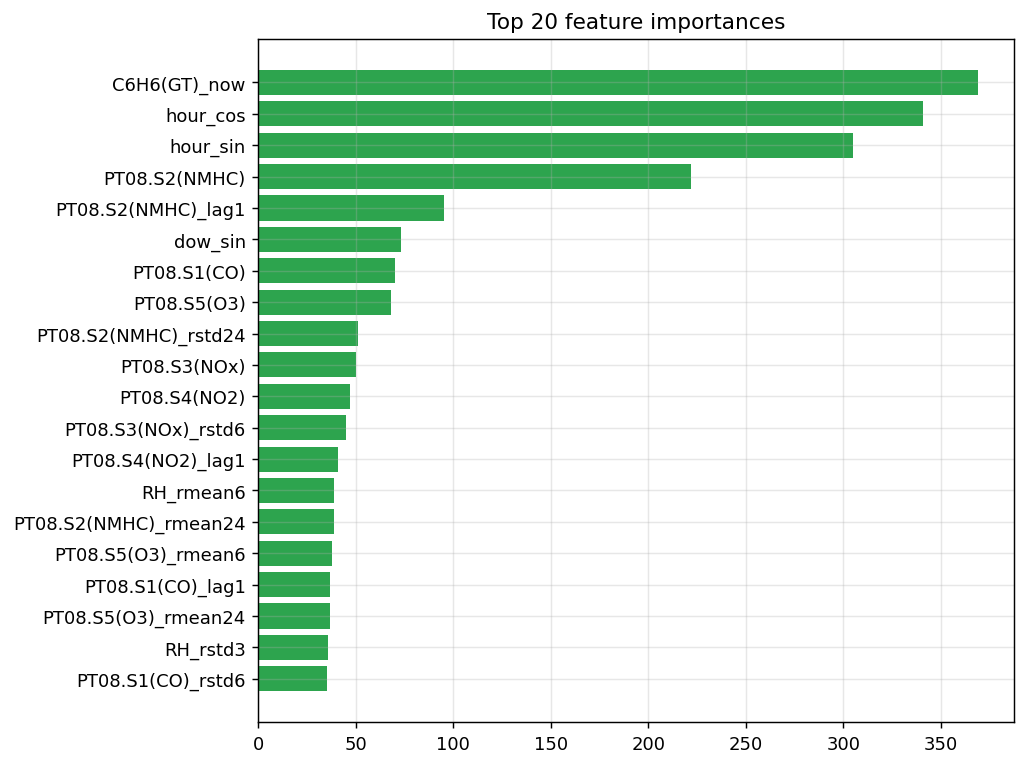

In [2]:
for f in ['05_predictions.png','06_residuals.png','07_model_comparison.png','08_feature_importance.png']:
    display(Image('../reports/figures/'+f))

### Conclusions

- **XGBoost wins** (RMSE ~2.24 micro-g/m^3, R^2 ~0.81, ~20% better than persistence). LightGBM is a close second.
- The **LSTM learns real structure (R^2 ~0.55) but does not beat persistence** at a 1-step horizon. This is expected: for a strongly autoregressive signal with only ~6k training hours, gradient-boosted trees on lag features are a very strong, hard-to-beat approach, while an LSTM needs more data / a longer horizon to pay off. Reporting this honestly is the point of including a baseline.
- Most important features are the **current benzene reading, the `PT08.S2` sensor, and short rolling means** - consistent with the physics of the sensor array.